# Assignment 3

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [1]:
%pip install tensorflow
%pip install keras_tuner

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from matplotlib import pyplot as plt
import keras_tuner as kt
from keras_tuner import HyperParameters

2026-02-02 13:10:19.647412: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-02 13:10:19.662758: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 13:10:20.482132: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/srv/conda/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_v

This lab continues our study of linear regression. You'll train your first models with Tensorflow, using a real dataset to predict car prices from their features. Note that Tensorflow is a rapidly changing library. This means you'll often see warnings about deprecations. You can ignore the warnings in our labs.

---
### Step 1: Data ingestion

You'll use the [Automobile Data Set](https://archive.ics.uci.edu/ml/datasets/automobile)  from 1985 Ward's Automotive Yearbook that is part of the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets).

This dataset has been pre-downloaded and uploaded to bCourses alongside this notebook for your convenience.

In [3]:
car_data_init = pd.read_csv("../data/automobile_data.txt")

# Display top five rows
print('Shape of data:', car_data_init.shape)
car_data_init.head()

Shape of data: (205, 26)


,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,symboling
0,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,3
1,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,3
2,NaN,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,1
3,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,2
4,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,2


---
### Step 2: Data preprocessing

This step is essential for preparing the data in a format that is suitable for ML algorithms. It helps ensure data quality and improvements in model performance.

### <span style="color:chocolate">Exercise 1:</span> Column selection (5 points)

To keep things simple, you will:

1. Retain only the following columns: ['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']. Name the new dataframe *car_data*.
2. Display the data type of each column;
3. Convert the data type of each columns to numeric. Coerce missing values to NaN. Hint: use <span style="color:chocolate">pd.to_numeric()</span> method;
4. Display the data type of each column after the transformation performed at point 3.


In [4]:
car_data =  car_data_init.loc[:, ['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']].copy()

print(f"{car_data.columns=}\n")
print(f"{car_data.dtypes=}\n")
car_data=car_data.apply(pd.to_numeric, errors="coerce")
print(f"{car_data.dtypes=}\n")

car_data.columns=Index(['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

car_data.dtypes=horsepower     float64
peak-rpm       float64
city-mpg         int64
highway-mpg      int64
price          float64
dtype: object

car_data.dtypes=horsepower     float64
peak-rpm       float64
city-mpg         int64
highway-mpg      int64
price          float64
dtype: object



### <span style="color:chocolate">Exercise 2:</span> Example (row) selection (5 points)

To keep things simple again, you will:

1. Print the shape of the car_data;

2. Remove examples (rows) that have missing value(s). Note that in doing so, you will overwrite the car_data dataset. You should end up with 199 examples after this cleaning.

3. Print the shape of the car_data again.

It's important to acknowledge that there are multiple approaches to handling missing features, and simply discarding examples with any missing feature, though straightforward, may not be the most optimal solution. However, for the sake of simplicity, you will implement this strategy in this assignment.

In [5]:
print(f"{car_data.shape=}")
car_data = car_data.dropna()
print(f"{car_data.shape=}")

car_data.shape=(205, 5)
car_data.shape=(199, 5)


### <span style="color:chocolate">Exercise 3:</span> Data shuffling (10 points)

Since you'll be using Batch Gradient Descent (BGD) for training, it is important that **each batch is a random sample of the data** so that the gradient computed is representative. Note that the original data (above) appears sorted by *make* in alphabetic order.

Using NumPy and Pandas methods:

1. Create a list of indices corresponding to the rows in the car_data dataset. Call this list *indices*. Print this list;

2. Shuffle *indices* using the <span style="color:chocolate">np.random.permutation()</span> method. Call the resulting array *shuffled_indices*. Print this array;
    
3. Use the method <span style="color:chocolate">dataframe.reindex()</span> to change the ordering of the car_data dataset based on the order in the *shuffled_indices* array. Note that in doing so, you will overwrite the original dataset. Print the top 5 rows.

In [6]:
np.random.seed(0)
indices = car_data.index
print(f"{indices=}")
shuffled_indices= np.random.permutation(indices)
print(f"{shuffled_indices=}")
car_data = car_data.reindex(shuffled_indices)
print(car_data.head(5))

indices=Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,  10,
       ...
       195, 196, 197, 198, 199, 200, 201, 202, 203, 204],
      dtype='int64', length=199)
shuffled_indices=array([ 19, 175, 109,  95, 182, 189,   5, 145,  13, 166,  64, 127, 170,
       151,  83,   7,  34, 135,  38,  77, 165, 150,  48, 164,  63, 125,
       184, 190, 100,  47,  17,  58,  86, 113,  23, 194, 141,   4, 143,
       199, 159,  69,  27, 137, 152,  66,   8,  78, 101, 172,  74, 202,
        89,  99, 155,  25,  31, 116,  41,  59, 136, 188, 186,  20, 158,
       142,  57, 168,  54, 115, 144,  92,  93, 126, 149, 187, 111,  15,
        28, 104, 121,  49, 200, 110,  65,   2,  62, 179, 132,  46,  11,
       192,  76, 197, 183, 173, 128,  96, 114, 163, 196,  53,   0,  97,
       112,  98,  67, 147,  42,  72,  52,  51,  88,  14, 156,  24, 191,
       140,  21,  16,  81, 107,  55, 103,  79,   3, 119, 169, 203,   6,
        71,  87, 124, 160, 176, 161,  94, 177,  12, 122, 105,  36,  60,
        68,   1, 123, 16

### <span style="color:chocolate">Exercise 4:</span> Define outcome and features (5 points)

Create two dataframes as follows:

1. The first dataframe contains our outcome of interest: ['price']. Note, this is what we are aiming to predict. Name this dataframe Y. Print shape of Y.
2. The second dataframe contains our features of interest: ['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']. Name this dataframe X. Print shape of X.


In [7]:
Y = pd.DataFrame(car_data['price'])
print(f"{Y.shape=}")

X = pd.DataFrame(car_data[['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']])
print(f"{X.shape=}")

Y.shape=(199, 1)
X.shape=(199, 4)


### <span style="color:chocolate">Exercise 5:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Partition the (X, Y) data into training, validation, and test sets using a splitting rule of [60%, 20%, 20%], with a random state set to 1234. Name the resulting dataframes as follows: X_train, X_val, X_test, Y_train, Y_val, Y_test. Hint: To create these three partitions you will utilize the train_test_split() method twice (all the other arguments of the method are set to default values.). You should obtain [119, 40, 40] examples for training, validation, and test, respectively.
2. Print the shape of each dataframe.

Note: The validation set is crucial for evaluating different hyperparameter configurations and selecting those that yield optimal model performance. This approach avoids utilizing the test dataset during model training, as it is assumed to be "unknown" at that stage.

In [8]:
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size = .2, random_state=1234)
print(f"{X_test.shape=}")
print(f"{Y_test.shape=}")
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size = .25, random_state=1234)
print(f"{X_train.shape=}")
print(f"{Y_train.shape=}")
print(f"{X_val.shape=}")
print(f"{Y_val.shape=}")

X_test.shape=(40, 4)
Y_test.shape=(40, 1)
X_train.shape=(119, 4)
Y_train.shape=(119, 1)
X_val.shape=(40, 4)
Y_val.shape=(40, 1)


### <span style="color:chocolate">Exercise 6:</span> Data standardization (10 points)

With this concept in mind, complete the following tasks:

1. Output the quantile values (0.25, 0.5, 0.75, 0.95) for all features in the X_train dataset. Are these values uniformly scaled across features?

2. Standardize all features in X_train, X_val, and X_test. Label the resulting dataframes as X_train_std, X_val_std, and X_test_std, respectively. Hint: standardize the validation and test data using the mean and standard deviation computed from the training data. Why?

3. Similar to point 2. but now standardize the outcome variable. Label the resulting dataframes as Y_train_std, Y_val_std, and Y_test_std.

In [9]:
X_train.quantile([.25, .5, .75, .95])

,horsepower,peak-rpm,city-mpg,highway-mpg
0.25,69.0,4800.0,21.0,25.0
0.50,90.0,5100.0,25.0,30.0
0.75,116.0,5400.0,31.0,37.0
0.95,176.6,5810.0,37.0,42.1


**Answer:**

These values are not uniformly scaled.

In [10]:
def scaled_df(df, scaler):
    return pd.DataFrame(scaler.transform(df), columns=df.columns, index=df.index)

x_scaler = StandardScaler()
x_scaler.fit(X_train)
X_train_std = scaled_df(X_train, x_scaler)
X_val_std = scaled_df(X_val, x_scaler)
X_test_std = scaled_df(X_test, x_scaler)

y_scaler = StandardScaler()
y_scaler.fit(Y_train)
Y_train_std = scaled_df(Y_train, y_scaler)
Y_val_std = scaled_df(Y_val, y_scaler)
Y_test_std = scaled_df(Y_test, y_scaler)

print(f"{X_train_std.mean()=}")
print(f"{Y_train_std.mean()=}")

X_train_std.mean()=horsepower    -1.077569e-16
peak-rpm       3.200055e-16
city-mpg      -1.679329e-16
highway-mpg    1.819273e-16
dtype: float64
Y_train_std.mean()=price    4.664803e-17
dtype: float64


---
### Step 3: Exploratory data analysis (EDA)

EDA plays a very important role in ML. The goal here is to develop a good understanding of our training dataset, identify any data quality issues, understand patterns and relationships, which in turn, aids in subsequent modeling and interpretations.

### <span style="color:chocolate">Exercise 7:</span> Scatterplot matrix (10 points)

In this exercise you will use some simple yet useful techniques to visualize the distribution of the data. 

Let's start with:

1. A scatterplot matrix to visualize the pair-wise correlations between different features and outcome in the (X_train_std, Y_train_std) data. You will use the <span style="color:chocolate">sns.pairplot()</span> method from the seaborn library imported at the top of the notebook;
2. Is any of the variables in the data normally distributed? Is it necessary for the explanatory or target variable to be normally distributed in order to train a ML model?

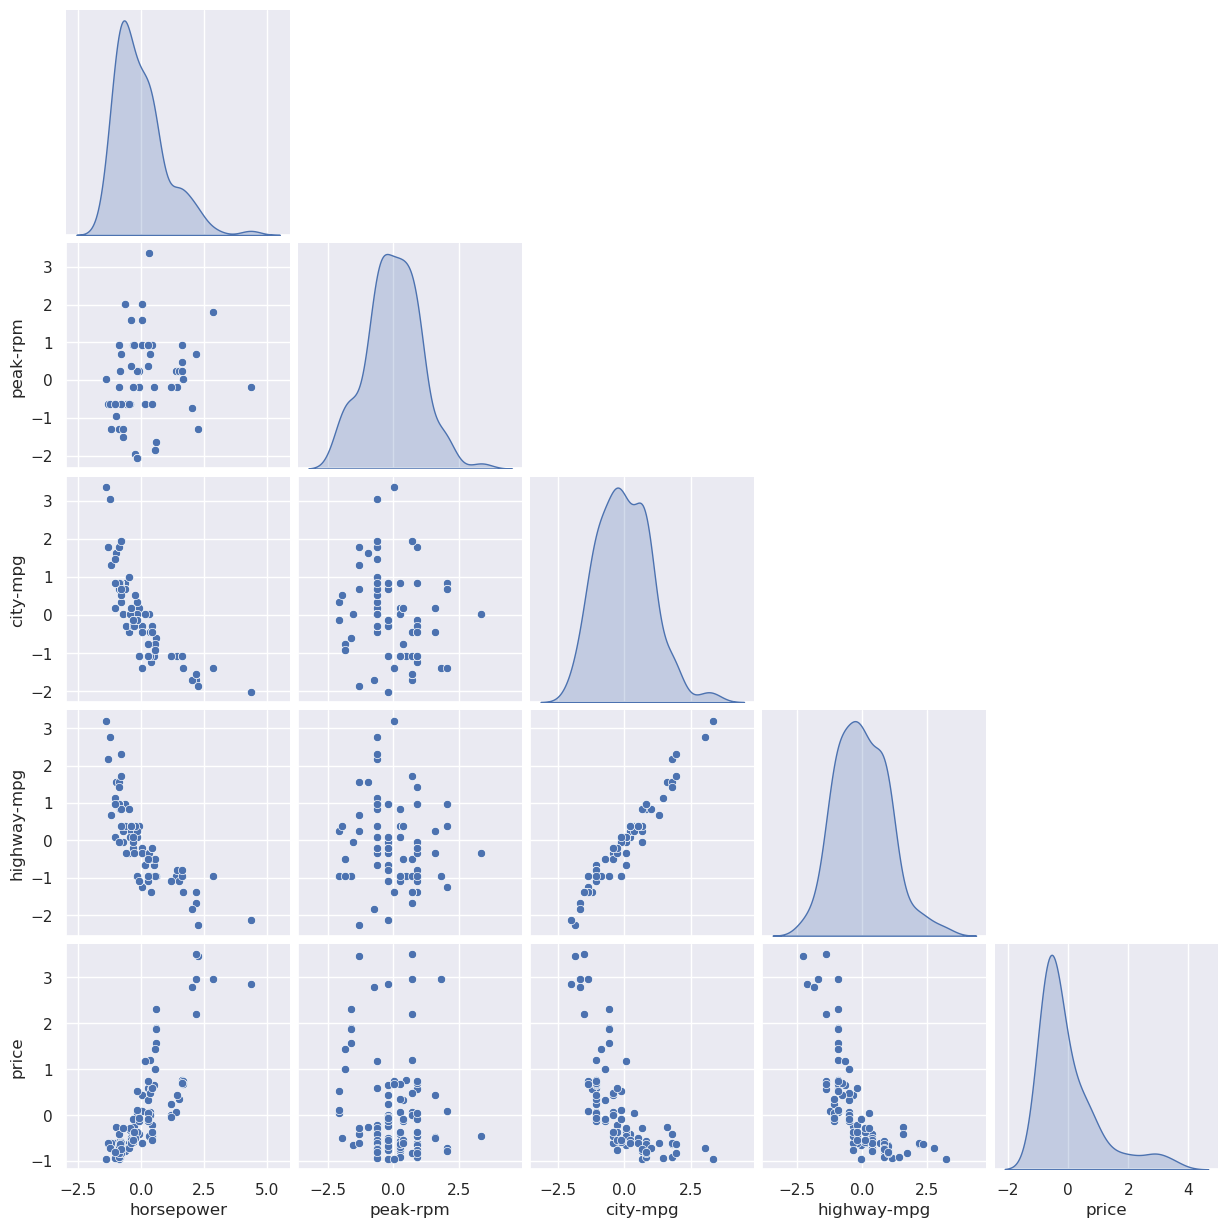

In [11]:
train_std = pd.concat([X_train_std, Y_train_std], axis=1)
sns.pairplot(train_std, corner=True, diag_kind="kde")
plt.show()

**Answer:**

`peak-rpm`, `highway-mpg`, `city-mpg` are all roughly normally distributed around mean 0

`price`, `horsepower` are skewed

It is not required for the target variable to be normally distributed in an ML model. There must be some relationship between the target and the explanatory variables for the model to tell us any meaningful information.

### <span style="color:chocolate">Exercise 8:</span> Correlation matrix (10 points)

In this exercise you will:

1. Plot a correlation matrix in the form of a heatmap to visualize the linear relationships between different features and outcome in the (X_train_std, Y_train_std) data. Hint: this example here is very useful: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
    
2. Answer the following questions: 
 - Which two features are likely to be most redundant?
 - Which feature is likely to be least useful for predicting price?

<Axes: >

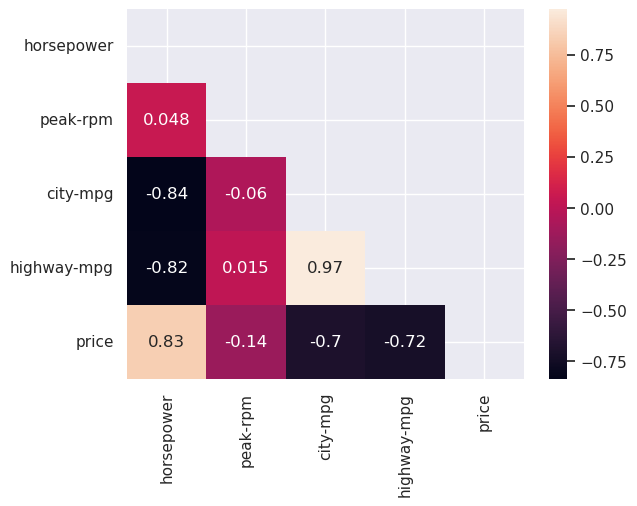

In [12]:
corr = train_std.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True)

**Answer 1:**

City MPG and Highway MPG are likely to be redundant because they are closely correlated together. This makes sense because cars with good gas mileare are likely to be high/low in both features simultaneously 

**Answer 2:**

Peak RPM has low correlation with the target variable, so it is unlikely to be helpful in predicting price.

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 9:</span> Baseline model (5 points)

Let's start by evaluating a baseline model. Precisely, you'll use the average price of cars in the training set as our baseline model -- that is, the baseline always predicts the average price regardless of the input.

1. Implement this baseline using the Y_train_std data and print the average price. Note: You can revert the price variable to the original scale for interpretation purposes.

In [13]:
print(X_train.index)
class AveragePrice():
    def __init__(self):
        self.mean = None
    def fit(self, x, y):
        self.mean = y.mean().iloc[0]
    def predict(self, test_df):
        index = test_df.index
        prediction = pd.DataFrame(index=index)
        prediction['prediction'] = self.mean
        return prediction
        
model1 = AveragePrice()
model1.fit(x = X_train_std, y = Y_train_std)
print(f"{model1.predict(Y_test).head(5)=}")

print(f"Dollar Value: ${y_scaler.inverse_transform([[model1.predict(Y_test).iloc[0,0]]])[0][0]}")

Index([ 97, 154,  63, 161, 140,  46,  23,  67, 128, 201,
       ...
       183,  24, 156, 172,  81,  80, 151,  48,  16,   7],
      dtype='int64', length=119)
model1.predict(Y_test).head(5)=       prediction
120  4.664803e-17
117  4.664803e-17
58   4.664803e-17
101  4.664803e-17
20   4.664803e-17
Dollar Value: $12889.008403361344


### <span style="color:chocolate">Exercise 10:</span> Improvement over Baseline with TensorFlow (10 points)

Let's train a linear regression model much like we did in the previous assignment, but this time using TensorFlow. 

1. Fill in the <span style="color:green">NotImplemented</span> parts of the build_model() function below by following the instructions provided as comments. Hint: refer to the course webpage in <span style="color:chocolate">bCourses/Modules/Module 03/live session demo</span> for an example.
2. Build and compile a model using the build_model() function and the (X_train_std, Y_train_std) data. Set learning_rate = 0.0001. Call the resulting object *model_tf*.
3. Train *model_tf* using the (X_train_std, Y_train_std) data. Set num_epochs = 5. Pass the (X_val_std, Y_val_std) data for validation. Hint: see the documentation behind the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method.
3. Generate a plot with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title. Hint: check what the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method returns.

More notes on point 1: the idea is to build a *computational graph* for linear regression, and then send data through it. There are many ways to build graphs, but [TenforFlow Keras API](https://www.tensorflow.org/api_docs/python/tf/keras) is recommended. 

In [14]:
def build_model(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # linear regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))

  # We need to choose an optimizer. We'll use GD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  # Finally, compile the model. This finalizes the graph for training.
  # We specify the MSE loss and the optimizer above
  model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=['mae']
  )
    
  return model

In [15]:
tf.random.set_seed(0)
# 2. Build and compile model
model_tf = build_model(X_train_std.shape[1], learning_rate = 0.0001)

# 3. Fit the model
model_history = model_tf.fit(
      x = X_train_std,
      y = Y_train_std,
      epochs=5,
      batch_size=1, #use all the data
      verbose=0, # silence the output
      validation_data=(X_val_std, Y_val_std)
)

/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-02 13:10:27.383550: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


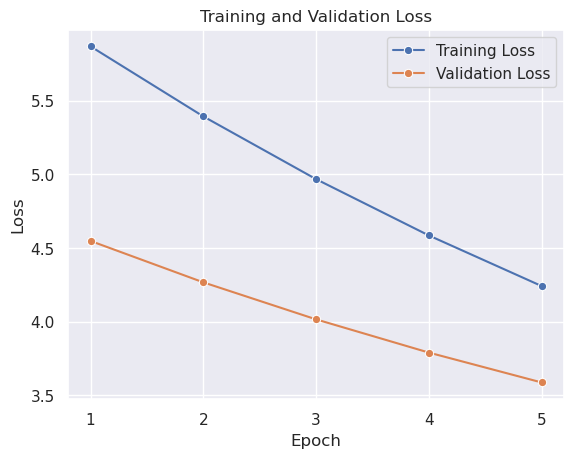

In [16]:
# 4. Plot errors

def plot_history(model_history):
    history = model_history.history
    epochs = range(1,len(history['loss'])+1)
    sns.lineplot(x=epochs, y=history['loss'], label="Training Loss", marker='o')
    sns.lineplot(x=epochs, y=history['val_loss'], label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.xticks(epochs)
    
    plt.show()
plot_history(model_history)

---
### Step 5: Hyperparameter tuning

Hyperparameter tuning is a crucial step in optimizing ML models. It involves systematically adjusting hyperparameters such as learning rate, number of epochs, and optimizer to find the model configuration that leads to the best generalization performance.

This tuning process is typically conducted by monitoring the model's performance on the validation vs. training set. It's important to note that using the test set for hyperparameter tuning can compromise the integrity of the evaluation process by violating the assumption of "blindness" of the test data.

### <span style="color:chocolate">Exercise 11:</span> Hyperparameter tuning (10 points)

1. Fine-tune the **learning rate** and **number of epochs** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). If you decide to work with the Keras Tuner, define a new model building function named <span style="color:chocolate">build_model_tuner()</span>.

After identifying your preferred model configuration, print the following information:

2. The learned parameters of the tuned model (this should include the bias term). Hint: use  <span style="color:chocolate">[model_name].layers[0].get_weights()</span>.
3. The loss at the final epoch on both the training and validation datasets;
4. The difference between the last-epoch loss observed on the training and validation datasets.


Please note that we will consider 'optimal model configuration' any last-epoch training loss that is below 0.31 and any last epoch validation loss that is below 0.48. Hint: do not specify the batch_size argument in the fit() function (it defaults to 32).

In [17]:
tf.random.set_seed(0)
def tune_hyperparams(epochs = 5, learning_rate = 0.0001):
    tuned_model = build_model(X_train_std.shape[1], learning_rate = learning_rate)

    history = tuned_model.fit(
        x = X_train_std,
        y = Y_train_std,
        epochs=epochs,
        batch_size=1, #use all the data
        verbose=0, # silence the output
        validation_data=(X_val_std, Y_val_std)
    )
    plot_history(history)
    print(f"Last epoch training loss = {history.history['loss'][-1]}")
    print(f"Last epoch validation loss = {history.history['val_loss'][-1]}")
    return tuned_model, history.history

/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


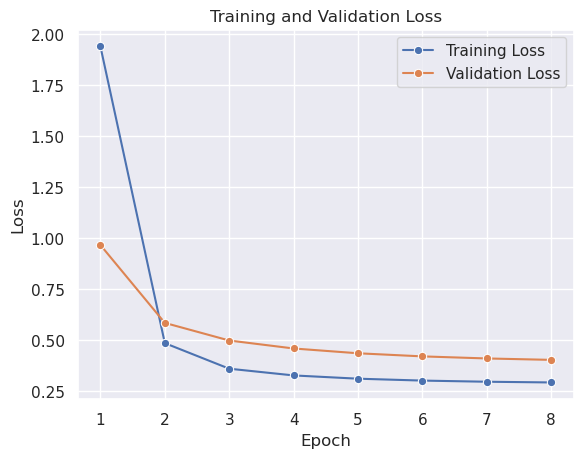

Last epoch training loss = 0.2932790517807007
Last epoch validation loss = 0.40395408868789673


In [18]:
pref_model, history = tune_hyperparams(8, 0.005)

In [19]:
"""
The learned parameters of the tuned model (this should include the bias term). Hint: use [model_name].layers[0].get_weights().
The loss at the final epoch on both the training and validation datasets;
The difference between the last-epoch loss observed on the training and validation datasets.
"""
weights = pref_model.layers[0].get_weights()
print(f"2. Preferred model weights = {weights}\n")

last_train_loss = history['loss'][-1]
last_val_loss = history['val_loss'][-1]
print("3.\n")
print(f"Last epoch training loss = {last_train_loss}")
print(f"Last epoch validation loss = {last_val_loss}")

print("\n4.")
print(f"Difference in last epoch loss (Validation - Training) = {last_val_loss - last_train_loss}")

2. Preferred model weights = [array([[ 0.88423586],
       [-0.19725943],
       [ 0.18724571],
       [-0.10661177]], dtype=float32), array([0.02974647], dtype=float32)]

3.

Last epoch training loss = 0.2932790517807007
Last epoch validation loss = 0.40395408868789673

4.
Difference in last epoch loss (Validation - Training) = 0.11067503690719604


---
### Step 6: Evaluation and Generalization


Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized (tuned) model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

### <span style="color:chocolate">Exercise 12:</span> Computing MSE (10 points)

1. Calculate the MSE on both (X_train_std, Y_train_std) and (X_test_std, Y_test_std) datasets. Hint: You can utilize the <span style="color:chocolate">model.evaluate()</span> method provided by tf.keras.

2. Does the model demonstrate strong generalization capabilities? Provide an explanation based on your observations. Hint: compare train vs. test MSE.

4. Generate a plot to visualize the accuracy of the predictions. Plot the actual (observed) Y_test values on the x-axis and the predicted Y_test values on the y-axis. Additionally, include a 45-degree line in the plot for reference. Ensure that the plot contains appropriate axis labels and a title. Provide commentary on the model's fit based on this visualization. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method available in tf.keras. 

In [20]:
train_loss_mae = pref_model.evaluate(X_train_std, Y_train_std)
print(f"Train Mean Squared Error = {train_loss_mae[0]}")
print(f"Train Mean Absolute Error = {train_loss_mae[1]}")

test_loss_mae = pref_model.evaluate(X_test_std, Y_test_std)
print(f"Test Mean Squared Error = {test_loss_mae[0]}")
print(f"Test Mean Absolute Error = {test_loss_mae[1]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2780 - mae: 0.3792 
Train Mean Squared Error = 0.27797144651412964
Train Mean Absolute Error = 0.37917187809944153
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2672 - mae: 0.3868
Test Mean Squared Error = 0.26719731092453003
Test Mean Absolute Error = 0.3867800831794739


**Answer 2:**

The model shows similar levels of Loss for the train and test sets, with the test set performing better than the training set. This indicates a model that generalizes well outside the training data.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


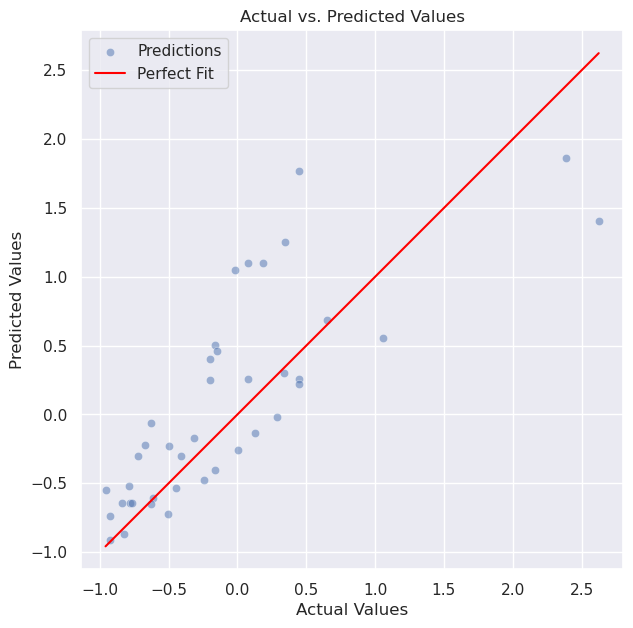

In [21]:
"""
Generate a plot to visualize the accuracy of the predictions.
Plot the actual (observed) Y_test values on the x-axis and the predicted Y_test values on the y-axis.
Additionally, include a 45-degree line in the plot for reference. Ensure that the plot contains appropriate axis labels and a title.
Provide commentary on the model's fit based on this visualization. Hint: You can utilize the model.predict() method available in tf.keras.
"""
predictions = pref_model.predict(X_test_std)
y_test = Y_test_std.values.flatten() 
y_predicted = predictions.flatten()
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_predicted, alpha=0.5, label='Predictions')
min_val = min(np.min(y_test), np.min(y_predicted))
max_val = max(np.max(y_test), np.max(y_predicted))
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Perfect Fit')
plt.title("Actual vs. Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.axis('equal')
plt.show()

**Commentary:**

The predicted values generally follow the same trend as the expectation. The model performs better on lower prices cars than higher priced cars. The plot shows heteroskedasticity, where the errors increase at higher prices. This is likely related to the right skew that was apparent in the price data.

----
### <span style="color:chocolate"></span> Additional practice (not graded)

In Exercise 12, you reported an aggregated MSE. Let's revisit the exercise by:

1. Performing a subgroup evaluation of the model. Specifically, calculate the test data MSE for the following makes: ['alfa-romero', 'audi', 'chevrolet', 'dodge', 'honda'].
2. Addressing the question: Is the model "fair" across each make?

In [22]:
# YOUR CODE HERE